In [16]:
!pip install opencv-python matplotlib scipy scikit-image pytesseract

In [17]:
!apt-get install tesseract-ocr

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [18]:
# Imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.ndimage import binary_fill_holes
from skimage.morphology import remove_small_objects
from skimage.measure import label, regionprops
import pytesseract

#### 0) Lectura de datos

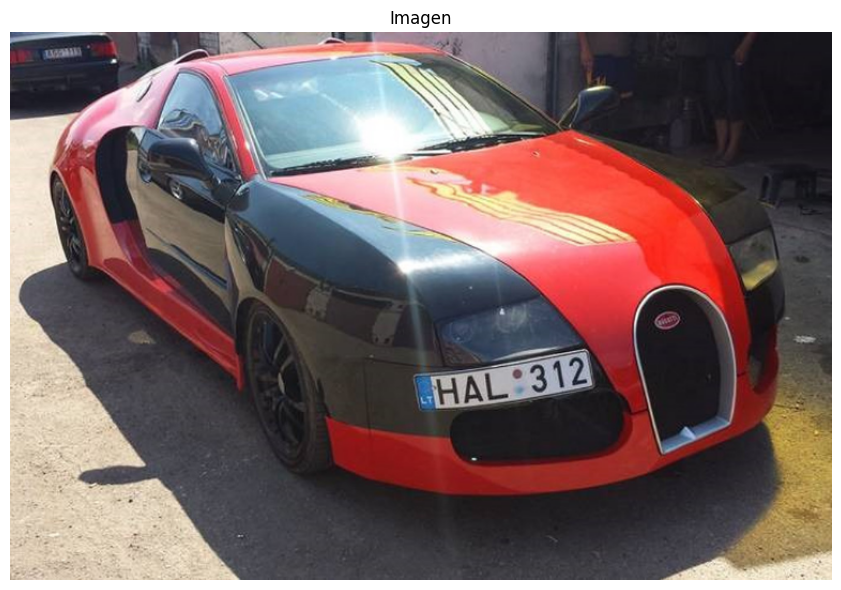

In [63]:
# Cargar la imagen 'auto_1.jpg' con opencv
img_bgr = cv2.imread('auto_5.jpg')

# Convertir la imagen a formato RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Redimensionar la imagen mediante el método de opencv "resize()" a un tamaño de (768,512)
img_rgb = cv2.resize(img_rgb, (768, 512))

# Visualizar la imagen
plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.title('Imagen')
plt.axis('off')
plt.tight_layout()
plt.show()

#### 1) Detección de bordes con Canny

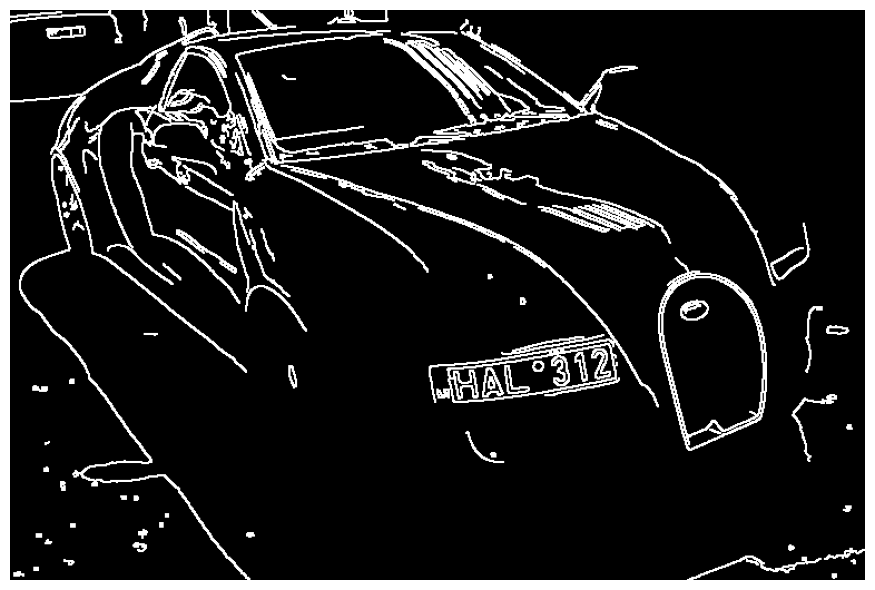

In [64]:
# Aplicar un filtro gaussiano con un kernel de 3x3
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
img_blur = cv2.GaussianBlur(img_gray, (3, 3), 0)

# Aplicar el método de Canny para la detección de bordes
edges = cv2.Canny(img_blur, 100, 200)

# Aplicar una dilatación con un kernel de 2x2 y 1 iteración
kernel_dilate = np.ones((2, 2), np.uint8)
edges_dilated = cv2.dilate(edges, kernel_dilate, iterations=1)

# Visualizar la máscara resultante
plt.figure(figsize=(10, 6))
plt.imshow(edges_dilated, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

#### 2) Procesamiento mediante operaciones morfológicas

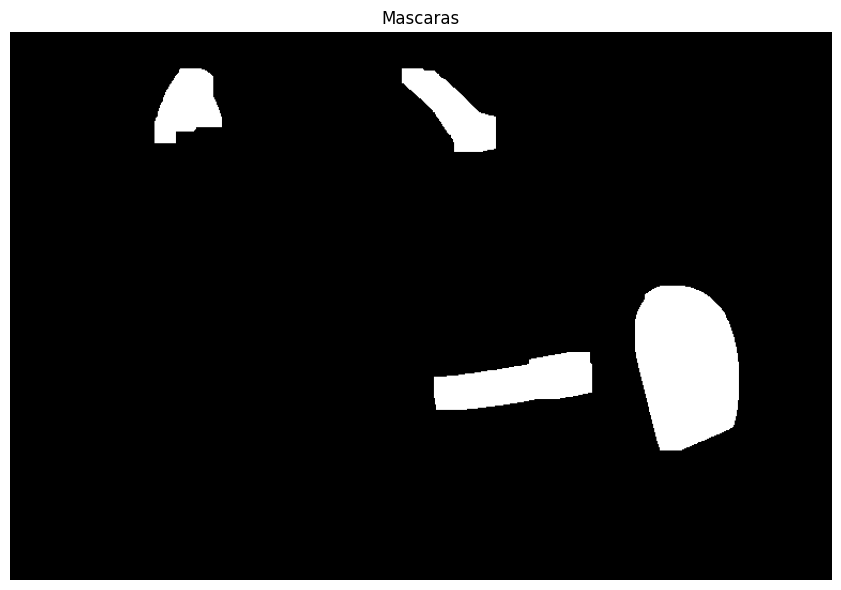

In [65]:
# Aplicar el comando "binary_fill_holes" sobre los bordes detectados
mask_filled = binary_fill_holes(edges_dilated).astype(np.uint8)

# Apertura vertical con kernel 20x1 para eliminar ruido vertical
kernel_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 20))
mask_open_v = cv2.morphologyEx(mask_filled, cv2.MORPH_OPEN, kernel_v, iterations=1)

# Apertura horizontal con kernel 1x20 para eliminar ruido horizontal
kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (20, 1))
mask_open_h = cv2.morphologyEx(mask_open_v, cv2.MORPH_OPEN, kernel_h, iterations=1)

# Eliminar objetos pequeños con area < 1000 pixeles
mask_clean = remove_small_objects(mask_open_h.astype(bool), min_size=1000, connectivity=8)
mask_clean = mask_clean.astype(np.uint8)

# Visualizar la mascara resultante
plt.figure(figsize=(10, 6))
plt.imshow(mask_clean, cmap='gray')
plt.title('Mascaras')
plt.axis('off')
plt.tight_layout()
plt.show()


#### 3) Detección automática de la región de interés correspondiente a la matrícula

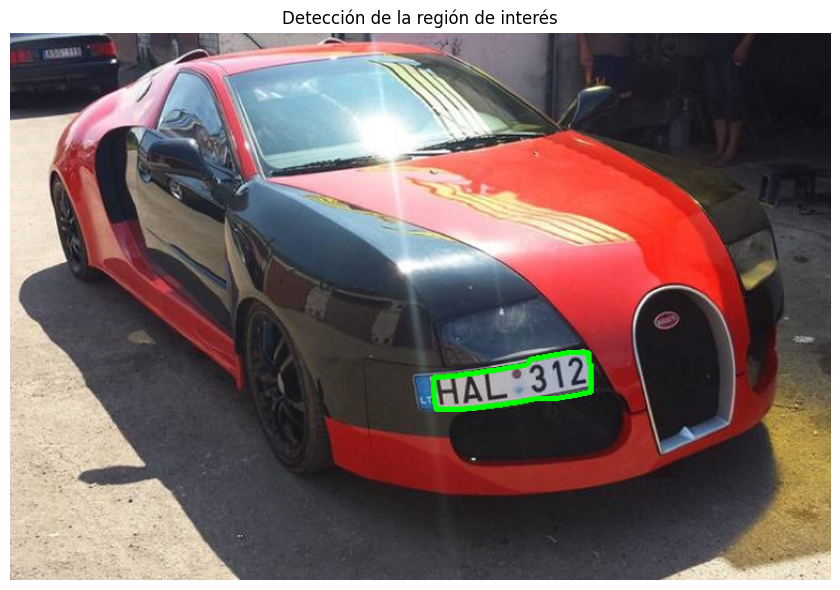

In [66]:
# Crear una imagen de etiquetas mediante el comando "label"
label_img = label(mask_clean)

# Calcular la proporción (cociente) entre el minor_axis_length y el major_axis_length para cada objeto de la imagen de etiquetas
props = regionprops(label_img)

ratios = []
for prop in props:
    if prop.major_axis_length > 0:
        ratio = prop.minor_axis_length / prop.major_axis_length
    else:
        ratio = 1
    ratios.append(ratio)

# Generar una máscara que contenga únicamente el objeto de la menor proporción.
min_ratio_idx = np.argmin(ratios)
target_label = props[min_ratio_idx].label
mask_plate = (label_img == target_label).astype(np.uint8)

# Dibujar los contornos de la máscara sobre la imagen original y visualizar el resultado
contours, _ = cv2.findContours(mask_plate, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_contours = img_rgb.copy()
cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 3)

plt.figure(figsize=(10, 6))
plt.imshow(img_contours)
plt.title('Detección de la región de interés')
plt.axis('off')
plt.tight_layout()
plt.show()

#### 4) Procesamiento de la región de interés

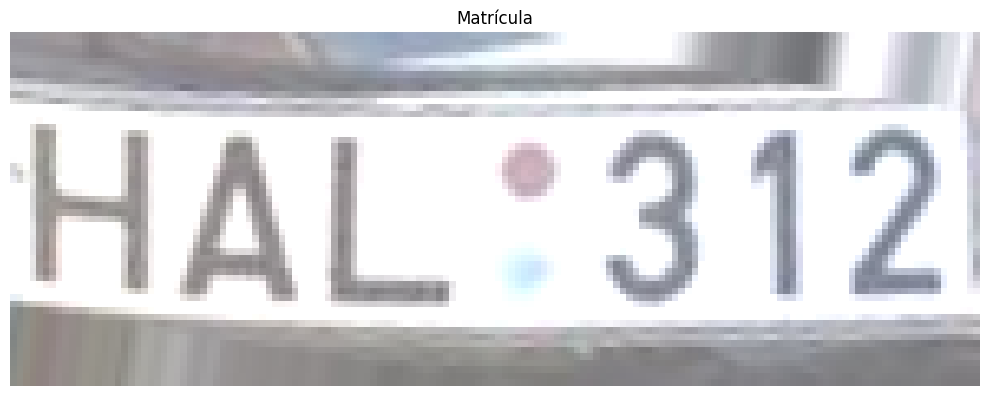

In [67]:
# Calcular la boundingbox de la máscara
plate_props = props[min_ratio_idx]
minr, minc, maxr, maxc = plate_props.bbox

# Hacer un crop de la imagen original a partir de las coordenadas de la boundingbox
img_crop = img_rgb[minr:maxr, minc:maxc]

# Calcular la orientación de la máscara.
orientation = plate_props.orientation

# Hacer una conversión mediante la siguiente fórmula:
    # angle = (orientation*90)/(math.pi/2). Nota: utilizar "import math"
    # Si 'angle' es mayor que 0, la orientación será igual a 90-angle
    # Si no, la orientación será igual a -(90+angle)
angle = (orientation * 90) / (math.pi / 2)
if angle > 0:
    angle_rot = 90 - angle
else:
    angle_rot = -(90 + angle)

# Aplicar una transformación geométrica de rotación para orientar horizontalmente el crop de la imagen obtenido anteriormente
h, w = img_crop.shape[:2]
center = (w // 2, h // 2)
rot_matrix = cv2.getRotationMatrix2D(center, angle_rot, 1.0)
img_rotated = cv2.warpAffine(img_crop, rot_matrix, (w, h),
                              flags=cv2.INTER_LINEAR,
                              borderMode=cv2.BORDER_REPLICATE)

# Aumentar el contraste 100 unidades de acuerdo a la fórmula vista en clase.
contrast_value = 100
img_contrast = np.clip(img_rotated.astype(np.int32) + contrast_value, 0, 255).astype(np.uint8)

# Visualizar el resultado la matrícula con el contraste aumentado
plt.figure(figsize=(10, 4))
plt.imshow(img_contrast)
plt.title('Matrícula')
plt.axis('off')
plt.tight_layout()
plt.show()

#### 5) Convertir el contenido de la imagen en un string mediante la librería 'pytesseract'
Para instalar la librería pytesseract:
    
    Descargar el ejecutable en -->  https://github.com/UB-Mannheim/tesseract/wiki
    Instalar la librería haciendo --> pip install pytesseract

Si se tienen dudas, consultar el siguiente vídeo:

    https://www.youtube.com/watch?v=_j6o2rBkhhg

Matrícula detectada: HAL312


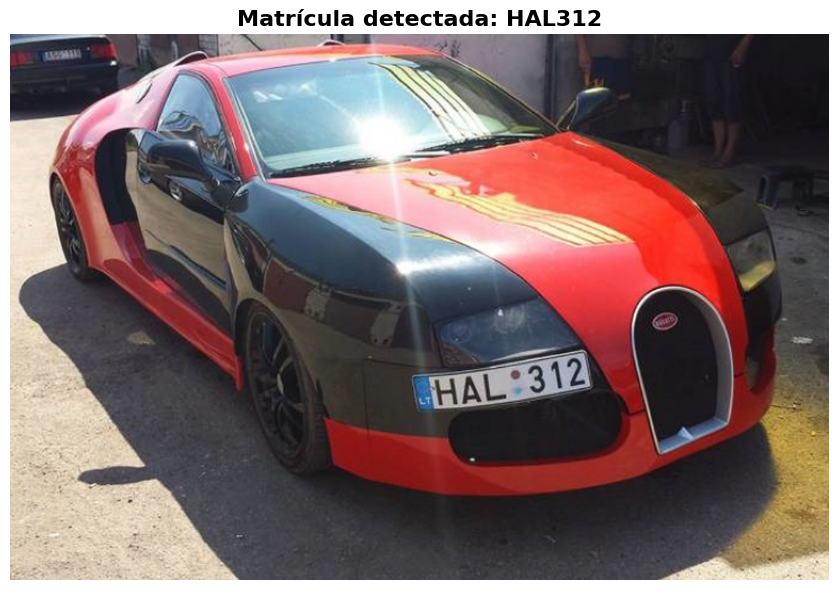

In [68]:
# Crear la ruta de pytesseract que contenga el ejecutable
pytesseract.pytesseract.tesseract_cmd = r'/usr/bin/tesseract'

# Convertir el contenido de la imagen en una variable de tipo string.
# Importante: utiliza la opción --> config='--psm 10'
string = pytesseract.image_to_string(img_contrast, config='--psm 10')

# Eliminar del string los caracteres especiales mediante la siguiente línea de código:
string = ''.join(filter(str.isalnum, string))

print(f'Matrícula detectada: {string}')

# Visualizar la imagen original y ponle el título extraído automáticamente mediante la librería "pytesseract"
plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.title(f'Matrícula detectada: {string}', fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()
